In [ ]:
from google.colab import files
files.upload()  # yah

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"adarshgupta07","key":"49728a9ea62ac83c25d4d5f5f613e0ad"}'}

In [ ]:
import os
from google.colab import files

# Define the standard Kaggle configuration directory
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_config_path = os.path.join(kaggle_dir, 'kaggle.json')

# Check if kaggle.json exists in the current directory (where files.upload() typically places it)
if os.path.exists('kaggle.json'):
    # If found, move it to the correct Kaggle directory
    os.rename('kaggle.json', kaggle_config_path)
    os.chmod(kaggle_config_path, 600)
    print("kaggle.json moved to {}".format(kaggle_config_path))
else:
    print("Error: 'kaggle.json' not found in the current directory. Please ensure you have uploaded it using `files.upload()` in a previous cell or re-run the upload cell.")


kaggle.json moved to /root/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:01<00:00, 123MB/s]



In [ ]:
import zipfile
with zipfile.ZipFile('cat-and-dog.zip', 'r') as zip_ref:
    zip_ref.extractall('cat_dog_data')

import os
print(os.listdir('cat_dog_data'))

['training_set', 'test_set']


In [ ]:
# Andar kya hai dekho
print(os.listdir('cat_dog_data/training_set'))
print(os.listdir('cat_dog_data/test_set'))

['training_set']
['test_set']


In [ ]:
print(os.listdir('cat_dog_data/training_set/training_set'))

['dogs', 'cats']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
train_path = 'cat_dog_data/training_set/training_set'
test_path = 'cat_dog_data/test_set/test_set'
transform=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
     transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
train_data = datasets.ImageFolder(train_path, transform=transform)
test_data=datasets.ImageFolder(test_path,transform=transform)
print("Training images:", len(train_data))
print("Testing images:", len(test_data))
print("Classes:", train_data.classes)


Training images: 8005
Testing images: 2023
Classes: ['cats', 'dogs']


In [ ]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)
print("Done!")

Done!


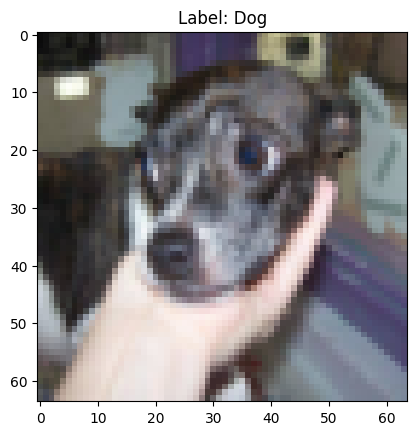

In [ ]:
images,labels=next(iter(train_loader))
plt.imshow(images[0].permute(1, 2, 0) * 0.5 + 0.5)
plt.title(f"Label: {'Dog' if labels[0] == 1 else 'Cat'}")
plt.show()

In [ ]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 512),
            nn.ReLU(),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = CatDogCNN()
print(model)

CatDogCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=2, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("Ready to train!")

Ready to train!


In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/5 — Loss: 0.6527
Epoch 2/5 — Loss: 0.5359
Epoch 3/5 — Loss: 0.4631
Epoch 4/5 — Loss: 0.3762
Epoch 5/5 — Loss: 0.2598


In [ ]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Model ki Accuracy: {accuracy:.2f}%")

Model ki Accuracy: 76.52%


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving pexels-gogul-s-1606744-33618815.jpg to pexels-gogul-s-1606744-33618815.jpg


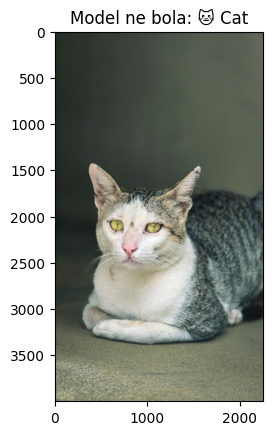

In [ ]:
from PIL import Image

# Uploaded file ka naam daalo
filename = list(uploaded.keys())[0]
img = Image.open(filename).convert('RGB')

# Transform karo
img_tensor = transform(img).unsqueeze(0)

# Predict karo
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)

plt.imshow(img)
plt.title(f"Model ne bola: {'🐶 Dog' if predicted.item()==1 else '🐱 Cat'}")
plt.show()